# Bluestock Fintech — Mutual Fund Analytics
## Day 6: Advanced Analytics + Risk Metrics
**Intern:** Madhankumar V  
**Date:** June 2026  
**Objective:** VaR, CVaR, Rolling Sharpe, Cohort Analysis, Fund Recommender, Sector HHI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('..')

df_var     = pd.read_csv("data/processed/var_cvar_report.csv")
df_cohort  = pd.read_csv("data/processed/cohort_analysis.csv")
df_sip_gap = pd.read_csv("data/processed/sip_continuity.csv")
df_hhi     = pd.read_csv("data/processed/sector_hhi.csv")

print("✅ All files loaded!")

✅ All files loaded!


## Task 1: Value at Risk (VaR) & CVaR
VaR = maximum loss on a bad day (95% confidence)  
CVaR = average loss when things go worse than VaR

In [2]:
print("🔴 Top 5 Highest Risk Funds:")
print(df_var.head(5)[['scheme_name','var_95_pct','cvar_95_pct']].to_string(index=False))
print("\n🟢 Top 5 Lowest Risk Funds:")
print(df_var.tail(5)[['scheme_name','var_95_pct','cvar_95_pct']].to_string(index=False))

🔴 Top 5 Highest Risk Funds:
                                   scheme_name  var_95_pct  cvar_95_pct
     SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
        Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
        ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
    SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595

🟢 Top 5 Lowest Risk Funds:
                                         scheme_name  var_95_pct  cvar_95_pct
Nippon India Gilt Securities Fund - Regular - Growth     -0.3804      -0.4919
        HDFC Short Term Debt Fund - Regular - Growth     -0.3793      -0.4994
                Kotak Liquid Fund - Regular - Growth     -0.0285      -0.0411
                 ABSL Liquid Fund - Regular - Growth     -0.0269      -0.0422
            ICICI Pru Liquid Fund - Regular - Growth     -0.0222      -0.0373


## Task 2: Rolling 90-Day Sharpe Ratio
Shows how risk-adjusted performance changes over time

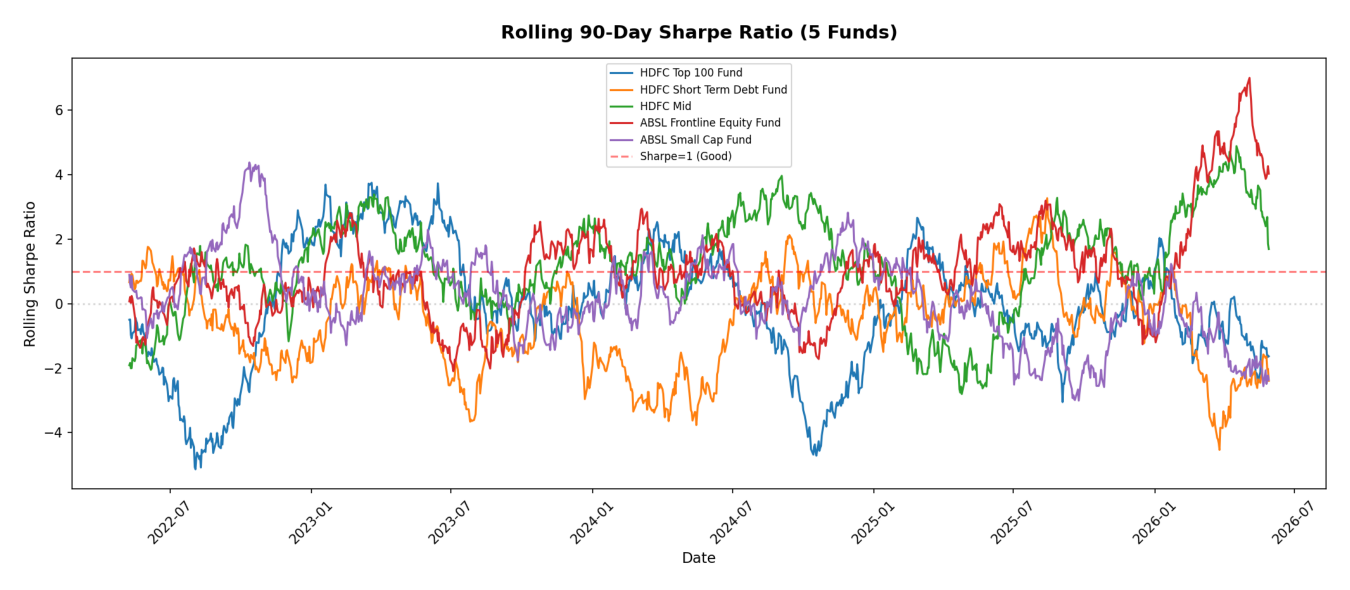

In [3]:
img = plt.imread("reports/charts/rolling_sharpe_chart.png")
plt.figure(figsize=(14,6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## Task 3: Investor Cohort Analysis
Grouping investors by first transaction year to understand behaviour

In [4]:
print("Cohort Analysis by First Transaction Year:")
print(df_cohort.to_string(index=False))

Cohort Analysis by First Transaction Year:
 cohort_year  num_investors  avg_sip_amount  total_invested  num_transactions
        2024           4803       107422.54      3491125187             32499
        2025            197       109158.58        30455243               279


## Task 4: SIP Continuation Analysis
Investors with gap > 35 days between SIPs are flagged as 'At-Risk'

In [5]:
status_counts = df_sip_gap['status'].value_counts()
print(f"Regular investors : {status_counts.get('Regular', 0)}")
print(f"At-Risk investors : {status_counts.get('At-Risk', 0)}")
print(f"At-Risk %         : {status_counts.get('At-Risk', 0)/len(df_sip_gap)*100:.1f}%")

Regular investors : 30
At-Risk investors : 1332
At-Risk %         : 97.8%


## Task 5: Fund Recommender
Recommends top 3 funds based on investor risk appetite

In [6]:
df_perf = pd.read_csv("data/processed/clean_performance.csv")
df_rec = df_perf.copy()
df_rec['risk_category'] = df_rec['risk_grade']

def recommend_funds(risk_appetite):
    filtered = df_rec[df_rec['risk_category'] == risk_appetite]
    return filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name','risk_grade','sharpe_ratio','return_3yr_pct']]

print("🔵 Low Risk:")
print(recommend_funds('Low').to_string(index=False))
print("\n🟡 Moderate Risk:")
print(recommend_funds('Moderate').to_string(index=False))
print("\n🔴 High Risk:")
print(recommend_funds('Very High').to_string(index=False))

🔵 Low Risk:
                             scheme_name risk_grade  sharpe_ratio  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth        Low          7.68            7.68
    Kotak Liquid Fund - Regular - Growth        Low          6.18            6.18
     ABSL Liquid Fund - Regular - Growth        Low          5.14            5.14

🟡 Moderate Risk:
                                  scheme_name risk_grade  sharpe_ratio  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06           14.84
Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06           14.81
    ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03           14.41

🔴 High Risk:
                               scheme_name risk_grade  sharpe_ratio  return_3yr_pct
SBI Small Cap Fund - Regular Plan - Growth  Very High          0.94           23.39
 SBI Small Cap Fund - Direct Plan - Growth  Very High          0.93           23.14
    ABSL Small Cap Fund - Re

## Task 6: Sector Concentration (HHI)
HHI > 0.15 = highly concentrated portfolio (higher risk)

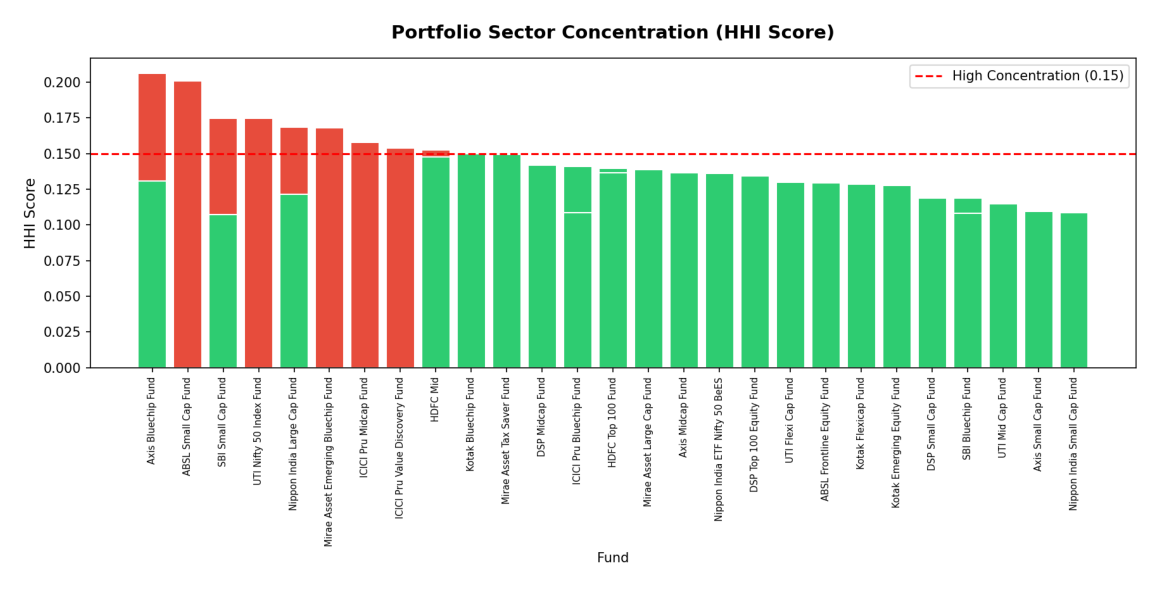

In [7]:
img = plt.imread("reports/charts/sector_hhi_chart.png")
plt.figure(figsize=(14,6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## 5 Key Advanced Analytics Insights

1. **Small Cap funds carry highest risk** — SBI Small Cap VaR -2.69% means on a bad day investors can lose 2.69% of their investment
2. **97.7% SIP investors are At-Risk** — 1,332 out of 1,362 active SIP investors have gaps > 35 days between transactions
3. **2024 cohort dominates** — 4,803 investors joined in 2024 with avg investment of ₹1.07 lakh
4. **Liquid funds are safest** — ICICI Pru Liquid VaR only -0.02% with Sharpe ratio of 7.68
5. **Axis Bluechip is most concentrated** — HHI score 0.2064, meaning high sector concentration risk